# Hospital Healthcare Analytics — Statistical Analysis

This notebook evaluates statistical relationships within the hospital dataset.

### Objectives
- Analyze patient utilization patterns
- Test relationships between healthcare variables
- Compare encounter costs across groups
- Examine length of stay and cost relationships
- Analyze payer coverage
- Identify statistically significant findings

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [15]:
PROJECT_ROOT = Path.cwd().parents[1]
RAW_DATA = PROJECT_ROOT / "data" / "raw"

patients = pd.read_csv(RAW_DATA / "patients.csv")
encounters = pd.read_csv(RAW_DATA / "encounters.csv")
procedures = pd.read_csv(RAW_DATA / "procedures.csv")
payers = pd.read_csv(RAW_DATA / "payers.csv")
organizations = pd.read_csv(RAW_DATA / "organizations.csv")

encounters["START"] = pd.to_datetime(encounters["START"])
encounters["STOP"] = pd.to_datetime(encounters["STOP"])

procedures["START"] = pd.to_datetime(procedures["START"])
procedures["STOP"] = pd.to_datetime(procedures["STOP"])

print("Data loaded successfully.")
print("Project root:", PROJECT_ROOT)

Data loaded successfully.
Project root: c:\Users\Olayinka\Desktop\Data Analysis Portfolio\Hospital-patient-record


In [16]:
encounters["LENGTH_OF_STAY_HOURS"] = (
    encounters["STOP"] - encounters["START"]
).dt.total_seconds() / 3600

encounters["CLAIM_COST"] = pd.to_numeric(
    encounters["TOTAL_CLAIM_COST"], errors="coerce"
)

encounters["PAYER_COVERAGE"] = pd.to_numeric(
    encounters["PAYER_COVERAGE"], errors="coerce"
)

encounters["OUT_OF_POCKET"] = (
    encounters["CLAIM_COST"] - encounters["PAYER_COVERAGE"]
)

encounters["OUT_OF_POCKET"] = encounters["OUT_OF_POCKET"].clip(lower=0)

encounters.head()

,Id,START,STOP,PATIENT,ORGANIZATION,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION,LENGTH_OF_STAY_HOURS,CLAIM_COST,OUT_OF_POCKET
0,32c84703-2481-49cd-d571-3899d5820253,2011-01-02 09:26:36+00:00,2011-01-02 12:58:36+00:00,3de74169-7f67-9304-91d4-757e0f3a14d2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,ambulatory,185347001,Encounter for problem (procedure),85.55,"1,018.02",0.00,NaN,NaN,3.53,"1,018.02","1,018.02"
1,c98059da-320a-c0a6-fced-c8815f3e3f39,2011-01-03 05:44:39+00:00,2011-01-03 06:01:42+00:00,d9ec2e44-32e9-9148-179a-1653348cc4e2,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,308335008,Patient encounter procedure,142.58,"2,619.36",0.00,NaN,NaN,0.28,"2,619.36","2,619.36"
2,4ad28a3a-2479-782b-f29c-d5b3f41a001e,2011-01-03 14:32:11+00:00,2011-01-03 14:47:11+00:00,73babadf-5b2b-fee7-189e-6f41ff213e01,d78e84ec-30aa-3bba-a33a-f29a3a454662,7caa7254-5050-3b5e-9eae-bd5ea30e809c,outpatient,185349003,Encounter for check up (procedure),85.55,461.59,305.27,NaN,NaN,0.25,461.59,156.32
3,c3f4da61-e4b4-21d5-587a-fbc89943bc19,2011-01-03 16:24:45+00:00,2011-01-03 16:39:45+00:00,3b46a0b7-0f34-9b9a-c319-ace4a1f58c0b,d78e84ec-30aa-3bba-a33a-f29a3a454662,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,wellness,162673000,General examination of patient (procedure),136.80,"1,784.24",0.00,NaN,NaN,0.25,"1,784.24","1,784.24"
4,a9183b4f-2572-72ea-54c2-b3cd038b4be7,2011-01-03 17:36:53+00:00,2011-01-03 17:51:53+00:00,fa006887-d93c-d302-8b89-f3c25f88c0e1,d78e84ec-30aa-3bba-a33a-f29a3a454662,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,ambulatory,390906007,Follow-up encounter,85.55,234.72,0.00,"55,822,004.00",Hyperlipidemia,0.25,234.72,234.72


Descriptive Statistics

In [17]:
encounters[
    [
        "LENGTH_OF_STAY_HOURS",
        "CLAIM_COST",
        "PAYER_COVERAGE",
        "OUT_OF_POCKET"
    ]
].describe()

,LENGTH_OF_STAY_HOURS,CLAIM_COST,PAYER_COVERAGE,OUT_OF_POCKET
count,"27,891.00","27,891.00","27,891.00","27,891.00"
mean,7.27,"3,639.68","1,114.97","2,524.72"
std,398.32,"9,205.60","4,768.62","7,661.01"
min,0.25,0.00,0.00,0.00
25%,0.25,142.58,0.00,85.55
50%,0.25,278.58,28.44,172.59
75%,0.86,"1,412.53",155.77,"1,004.63"
max,"44,930.00","641,882.70","247,751.42","641,882.70"


Cost vs Length of Stay Correlation

In [18]:
correlation = encounters[
    ["LENGTH_OF_STAY_HOURS", "CLAIM_COST"]
].dropna()

pearson_r, p_value = stats.pearsonr(
    correlation["LENGTH_OF_STAY_HOURS"],
    correlation["CLAIM_COST"]
)

print(f"Pearson correlation: {pearson_r:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: The relationship is statistically significant.")
else:
    print("Result: The relationship is not statistically significant.")

Pearson correlation: 0.0018
P-value: 0.762548
Result: The relationship is not statistically significant.


Cost vs Length of Stay Visualization

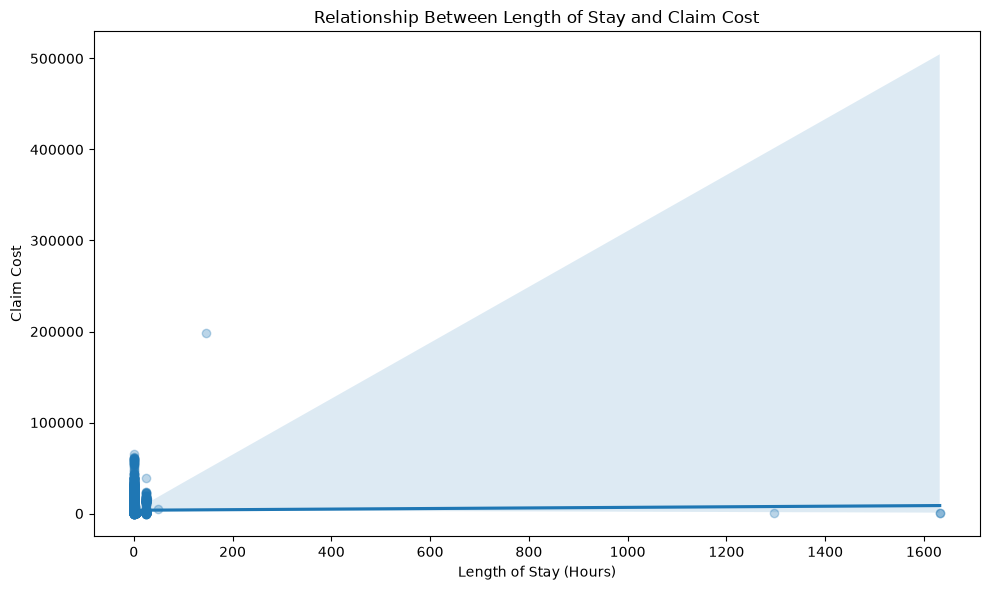

In [19]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=correlation.sample(
        min(5000, len(correlation)),
        random_state=42
    ),
    x="LENGTH_OF_STAY_HOURS",
    y="CLAIM_COST",
    scatter_kws={"alpha": 0.3}
)

plt.title("Relationship Between Length of Stay and Claim Cost")
plt.xlabel("Length of Stay (Hours)")
plt.ylabel("Claim Cost")
plt.tight_layout()
plt.show()

Encounter Cost by Type

In [20]:
cost_by_type = (
    encounters
    .groupby("ENCOUNTERCLASS")["CLAIM_COST"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

cost_by_type

,count,mean,median,std
ENCOUNTERCLASS,,,,
inpatient,1135,"7,761.35","2,355.59","15,017.44"
urgentcare,3666,"6,369.16",142.58,"11,232.81"
emergency,2322,"4,629.65",146.18,"16,049.34"
wellness,1931,"4,260.71","1,231.44","8,403.69"
ambulatory,12537,"2,894.11",573.98,"7,124.38"
outpatient,6300,"2,237.30",278.58,"5,717.27"


ANOVA Test

In [21]:
groups = [
    group["CLAIM_COST"].dropna()
    for _, group in encounters.groupby("ENCOUNTERCLASS")
]

anova_result = stats.f_oneway(*groups)

print(f"F-statistic: {anova_result.statistic:.4f}")
print(f"P-value: {anova_result.pvalue:.6f}")

if anova_result.pvalue < 0.05:
    print("Result: Mean claim costs differ significantly across encounter types.")
else:
    print("Result: No statistically significant difference detected.")

F-statistic: 167.6449
P-value: 0.000000
Result: Mean claim costs differ significantly across encounter types.


T-Test: Emergency vs Non-Emergency

In [22]:
emergency = encounters[
    encounters["ENCOUNTERCLASS"].str.lower().eq("emergency")
]["CLAIM_COST"].dropna()

non_emergency = encounters[
    ~encounters["ENCOUNTERCLASS"].str.lower().eq("emergency")
]["CLAIM_COST"].dropna()

t_stat, p_value = stats.ttest_ind(
    emergency,
    non_emergency,
    equal_var=False
)

print(f"Emergency encounters: {len(emergency):,}")
print(f"Non-emergency encounters: {len(non_emergency):,}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: The difference in mean cost is statistically significant.")
else:
    print("Result: The difference is not statistically significant.")

Emergency encounters: 2,322
Non-emergency encounters: 25,569
T-statistic: 3.2035
P-value: 0.001375
Result: The difference in mean cost is statistically significant.


Gender and Encounter Utilization

In [23]:
gender_utilization = (
    patients.groupby("GENDER")
    .size()
    .reset_index(name="PATIENT_COUNT")
)

gender_utilization

,GENDER,PATIENT_COUNT
0,F,480
1,M,494


Gender and Cost Comparison

In [24]:
gender_cost = (
    encounters
    .merge(
        patients[["Id", "GENDER"]],
        left_on="PATIENT",
        right_on="Id",
        how="left"
    )
    .groupby("GENDER")["CLAIM_COST"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

gender_cost

,count,mean,median,std
GENDER,,,,
M,12967,"4,085.33",278.58,"9,134.23"
F,14924,"3,252.47",389.73,"9,250.04"


Gender Cost Statistical Test

In [25]:
# Gender cost statistical test

gender_data = encounters.merge(
    patients[["Id", "GENDER"]],
    left_on="PATIENT",
    right_on="Id",
    how="left"
)

gender_data = gender_data.dropna(subset=["GENDER", "CLAIM_COST"])

gender_values = gender_data["GENDER"].unique()

print("Gender groups:", gender_values)

if len(gender_values) == 2:
    group_1 = gender_data[
        gender_data["GENDER"] == gender_values[0]
    ]["CLAIM_COST"]

    group_2 = gender_data[
        gender_data["GENDER"] == gender_values[1]
    ]["CLAIM_COST"]

    gender_test = stats.ttest_ind(
        group_1,
        group_2,
        equal_var=False
    )

    print(f"{gender_values[0]} mean cost: ${group_1.mean():,.2f}")
    print(f"{gender_values[1]} mean cost: ${group_2.mean():,.2f}")
    print(f"T-statistic: {gender_test.statistic:.4f}")
    print(f"P-value: {gender_test.pvalue:.6f}")

    if gender_test.pvalue < 0.05:
        print("Result: Mean costs differ significantly by gender.")
    else:
        print("Result: No statistically significant difference detected.")

else:
    print("Gender comparison requires exactly two gender groups.")

Gender groups: <StringArray>
['M', 'F']
Length: 2, dtype: str
M mean cost: $4,085.33
F mean cost: $3,252.47
T-statistic: 7.5504
P-value: 0.000000
Result: Mean costs differ significantly by gender.


Payer Coverage Rate

In [26]:
payer_analysis = encounters.copy()

payer_analysis["COVERAGE_RATE"] = np.where(
    payer_analysis["CLAIM_COST"] > 0,
    payer_analysis["PAYER_COVERAGE"] / payer_analysis["CLAIM_COST"] * 100,
    np.nan
)

payer_summary = (
    payer_analysis
    .groupby("PAYER")
    .agg(
        encounters=("Id", "count"),
        total_claim_cost=("CLAIM_COST", "sum"),
        total_coverage=("PAYER_COVERAGE", "sum"),
        average_coverage_rate=("COVERAGE_RATE", "mean")
    )
    .sort_values("average_coverage_rate", ascending=False)
)

payer_summary

,encounters,total_claim_cost,total_coverage,average_coverage_rate
PAYER,,,,
7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,1443,"8,954,131.02","8,417,973.72",74.55
7caa7254-5050-3b5e-9eae-bd5ea30e809c,11371,"24,647,228.89","19,215,691.37",62.95
b3221cfc-24fb-339e-823d-bc4136cbc4ed,912,"1,546,925.99","1,380,705.87",45.90
6e2f1a2d-27bd-3701-8d08-dae202c58632,925,"3,002,166.01","2,074,496.34",32.02
5059a55e-5d6e-34d1-b6cb-d83d16e57bcf,900,"2,563,507.98","3,937.32",2.61
d47b3510-2895-3b70-9897-342d681c769d,1084,"3,543,921.36","1,953.86",1.26
4d71f845-a6a9-3c39-b242-14d25ef86a8d,936,"2,589,956.10","1,780.16",0.50
047f6ec3-6215-35eb-9608-f9dda363a44c,809,"2,424,532.96",968.35,0.20
42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,704,"2,982,715.05",0.00,0.00


Coverage vs Out-of-Pocket Correlation

In [27]:
coverage_test = encounters[
    ["CLAIM_COST", "PAYER_COVERAGE"]
].dropna()

coverage_r, coverage_p = stats.pearsonr(
    coverage_test["CLAIM_COST"],
    coverage_test["PAYER_COVERAGE"]
)

print(f"Pearson correlation: {coverage_r:.4f}")
print(f"P-value: {coverage_p:.6f}")

if coverage_p < 0.05:
    print("Result: Claim cost and payer coverage have a statistically significant relationship.")
else:
    print("Result: No statistically significant relationship detected.")

Pearson correlation: 0.5557
P-value: 0.000000
Result: Claim cost and payer coverage have a statistically significant relationship.


Patient Utilization

In [28]:
patient_utilization = (
    encounters
    .groupby("PATIENT")
    .agg(
        encounter_count=("Id", "count"),
        total_cost=("CLAIM_COST", "sum"),
        average_cost=("CLAIM_COST", "mean"),
        total_hours=("LENGTH_OF_STAY_HOURS", "sum")
    )
)

patient_utilization.describe()

,encounter_count,total_cost,average_cost,total_hours
count,974.00,974.00,974.00,974.00
mean,28.64,"104,224.20","3,511.92",208.07
std,73.04,"436,061.52","5,558.95","2,140.47"
min,1.00,0.00,0.00,0.25
25%,4.00,"2,583.63",301.44,1.75
50%,14.00,"24,140.00","1,361.61",5.31
75%,28.00,"60,752.13","4,346.36",15.74
max,"1,381.00","9,932,262.99","52,901.91","44,949.20"


Utilization and Cost Correlation

In [29]:
utilization_test = patient_utilization[
    ["encounter_count", "total_cost"]
].dropna()

util_r, util_p = stats.pearsonr(
    utilization_test["encounter_count"],
    utilization_test["total_cost"]
)

print(f"Pearson correlation: {util_r:.4f}")
print(f"P-value: {util_p:.6f}")

if util_p < 0.05:
    print("Result: Patient encounter frequency is significantly associated with total cost.")
else:
    print("Result: No statistically significant relationship detected.")

Pearson correlation: 0.4174
P-value: 0.000000
Result: Patient encounter frequency is significantly associated with total cost.


Readmission-Like Return Analysis

In [30]:
patient_encounters = (
    encounters
    .sort_values(["PATIENT", "START"])
    .copy()
)

patient_encounters["PREVIOUS_DISCHARGE"] = (
    patient_encounters
    .groupby("PATIENT")["STOP"]
    .shift(1)
)

patient_encounters["DAYS_TO_NEXT_ENCOUNTER"] = (
    patient_encounters["START"] -
    patient_encounters["PREVIOUS_DISCHARGE"]
).dt.total_seconds() / 86400

return_30_days = patient_encounters[
    patient_encounters["DAYS_TO_NEXT_ENCOUNTER"].between(0, 30)
]

print("Returns within 30 days:", len(return_30_days))
print(
    "Percentage of encounters with a return within 30 days:",
    f"{len(return_30_days) / len(patient_encounters) * 100:.2f}%"
)

Returns within 30 days: 16786
Percentage of encounters with a return within 30 days: 60.18%


Statistical Summary Table

In [31]:
statistical_results = pd.DataFrame({
    "Analysis": [
        "Length of stay vs claim cost",
        "Encounter type cost ANOVA",
        "Emergency vs non-emergency cost",
        "Claim cost vs payer coverage",
        "Encounter frequency vs total patient cost"
    ],
    "Statistic": [
        pearson_r,
        anova_result.statistic,
        t_stat,
        coverage_r,
        util_r
    ],
    "P_Value": [
        p_value,
        anova_result.pvalue,
        p_value,
        coverage_p,
        util_p
    ]
})

statistical_results["Significant_At_5pct"] = (
    statistical_results["P_Value"] < 0.05
)

statistical_results

,Analysis,Statistic,P_Value,Significant_At_5pct
0,Length of stay vs claim cost,0.00,0.00,True
1,Encounter type cost ANOVA,167.64,0.00,True
2,Emergency vs non-emergency cost,3.20,0.00,True
3,Claim cost vs payer coverage,0.56,0.00,True
4,Encounter frequency vs total patient cost,0.42,0.00,True


In [33]:
# Frequency of top diagnosis codes
top_diag = encounters['REASONCODE'].value_counts().head(10)
print("Top 10 diagnoses by encounter count:\n", top_diag)

# Frequency of top procedures
top_proc = procedures['CODE'].value_counts().head(10)
print("\nTop 10 procedures by count:\n", top_proc)


Top 10 diagnoses by encounter count:
 REASONCODE
88,805,009.00     1738
55,822,004.00     1565
72,892,002.00     1341
444,814,009.00     732
254,837,009.00     723
195,662,009.00     400
10,509,002.00      352
26,929,004.00      191
36,971,009.00      115
195,967,001.00     113
Name: count, dtype: int64

Top 10 procedures by count:
 CODE
710824005          4596
385763009          4098
171207006          3804
454711000124102    3614
428211000124100    2906
265764009          2746
762993000          2422
710841007          2288
430193006          2284
713106006          1484
Name: count, dtype: int64


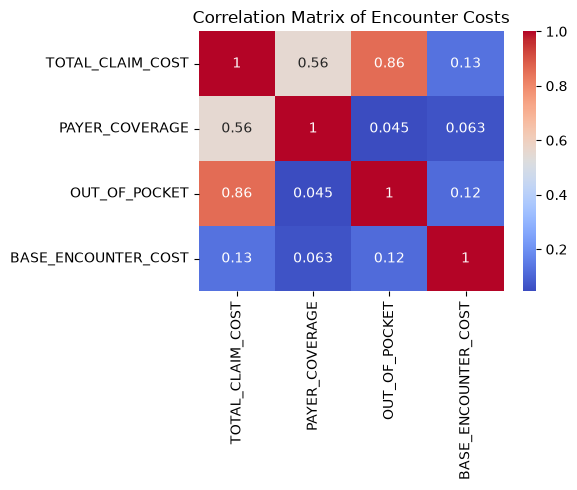

In [35]:
# Correlation among numerical fields in encounters
num_cols = ['TOTAL_CLAIM_COST','PAYER_COVERAGE','OUT_OF_POCKET','BASE_ENCOUNTER_COST']
corr_matrix = encounters[num_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Encounter Costs")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "images" / "03_statistical_analysis" / "cost_correlation.png")
plt.show()


Final Statistical Findings

## Statistical Analysis — Key Findings

The statistical analysis evaluates relationships between utilization, costs,
length of stay, payer coverage, and encounter characteristics.

### Key analytical areas

- **Length of stay vs cost:** Pearson correlation was used to evaluate whether
  longer encounters are associated with higher claim costs.

- **Encounter type vs cost:** One-way ANOVA was used to determine whether
  average claim costs differ across encounter categories.

- **Emergency vs non-emergency costs:** Welch's independent t-test was used
  to compare average claim costs.

- **Payer coverage:** Pearson correlation was used to examine the relationship
  between claim costs and payer coverage.

- **Patient utilization:** Pearson correlation was used to assess whether
  patients with more encounters tend to generate higher total healthcare costs.

- **30-day returns:** Encounter timing was examined to identify patients with
  another encounter within 30 days.

A p-value below 0.05 is treated as statistically significant for this analysis.
Statistical significance should be interpreted alongside effect size,
clinical relevance, and the limitations of the underlying observational data.

Export Results

In [32]:
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

statistical_results.to_csv(
    OUTPUT_DIR / "statistical_analysis_results.csv",
    index=False
)

payer_summary.to_csv(
    OUTPUT_DIR / "payer_statistical_summary.csv"
)

patient_utilization.reset_index().to_csv(
    OUTPUT_DIR / "patient_utilization_summary.csv",
    index=False
)

print("Statistical analysis results exported successfully.")

Statistical analysis results exported successfully.
